In [12]:
import pandas as pd
import os

# If not already in sys.path, add the folder where ship_pairing.py lives:
# import sys; sys.path.append("/path/to/your/module/folder")

from utils.ship_sightings import (
    ID_COL, SHIP_COL, DATE_COL, LAT_COL, LON_COL, WDBEAR_COL, BF_COL, SIGHT_COL,
    filter_ship_sighting_rows, build_sighting_pairs, materialize_close_pairs)

#read in 
current_directory = os.getcwd()
Figures = os.path.join(current_directory, 'Manuscript Figures')
CSV = os.path.join(current_directory, 'CSV_files')
PKL = os.path.join(current_directory, 'PKL')

df = pd.read_csv(os.path.join(CSV, "Final_tier4_2025-08-26.csv"))

In [13]:
# extract sighting rows (slimmed columns; dates/coords normalized)
df_sight = filter_ship_sighting_rows(df)
df_sight.head()

,ID,LogBook ID,Entry Date Time,Latitude_decimal,Longitude_decimal,WD_Bearing,BF Value,Ship Sightings
1029,19617,Abigail (ship) 1847-1850,1847-11-25 12:00:00,NaN,NaN,90.0,2.0,"""spoke...the Washington of Nantucket...the Bar..."
1030,19618,Abigail (ship) 1847-1850,1847-11-26 12:00:00,NaN,NaN,0.0,6.0,"""the 2 ships (Washington & Bark Hope) in company"""
1032,19620,Abigail (ship) 1847-1850,1847-11-28 12:00:00,NaN,NaN,NaN,6.0,"""the Bark Hope in company"""
1033,19622,Abigail (ship) 1847-1850,1847-11-29 12:00:00,21.616667,NaN,NaN,6.0,"""the Bark (Hope) in company"""
1034,19623,Abigail (ship) 1847-1850,1847-11-30 12:00:00,NaN,NaN,NaN,6.0,"""the Bark (Hope) in company"""


In [14]:
# build candidate pairs (name match + year-overlap; creates Target_ID)
pairs_v2 = build_sighting_pairs(df, df_sight)

print(f"Candidate name+year pairs: {len(pairs_v2)}")
display(pairs_v2.head())

Candidate name+year pairs: 526


,ID_1,LogBookID_1,Date_1,Latitude_1,Longitude_1,Wind Force_1,Bearing_1,Sight_Text,Target_LogBookID,Target_NameKey,Target_Start_Year,Target_End_Year,Target_ID
0,66364,Abraham Barker (Ship) 1850-185…,1851-07-02 12:00:00,NaN,NaN,1.0,NaN,The Gideon Howland The Trident,Trident (Ship) 1850-1854,trident,1850,1854,Trident__1851
1,66368,Abraham Barker (Ship) 1850-185…,1851-07-06 12:00:00,64.166667,-173.333333,2.0,135.0,The Braganza The Midas The Trident The Liverpool,Trident (Ship) 1850-1854,trident,1850,1854,Trident__1851
2,66415,Abraham Barker (Ship) 1850-185…,1851-08-08 12:00:00,NaN,NaN,NaN,NaN,The Constitution The Trident,Trident (Ship) 1850-1854,trident,1850,1854,Trident__1851
3,67209,Abraham Barker (Ship) 1850-185…,1852-05-20 12:00:00,57.083333,NaN,2.0,45.0,Arab of Fair Haven,Arab (Ship) 1849-1853,arab,1849,1853,Arab__1852
4,67209,Abraham Barker (Ship) 1850-185…,1852-05-20 12:00:00,57.083333,NaN,2.0,45.0,Arab of Fair Haven,Arab (ship) 1852-1853,arab,1852,1853,Arab__1852


In [15]:
# impose spatial/temporal restrictions (≤200 km, ≤1 day)
df_pairs = materialize_close_pairs(df, pairs_v2, max_km=200.0, max_days=1)

print(f"Close-in matches (<=200km, <=1 day): {len(df_pairs)}")
display(df_pairs.head())

Close-in matches (<=200km, <=1 day): 156


,ID_1,LogBookID_1,Date_1,Latitude_1,Longitude_1,Wind Force_1,Bearing_1,ID_2,LogBookID_2,Date_2,Latitude_2,Longitude_2,Wind Force_2,Bearing_2,Sight_Text,Target_ID,Distance_km,Delta_days
0,67294,Abraham Barker (Ship) 1850-185…,1852-06-20 12:00:00,59.300000,-178.050000,5.0,337.5,101762,Navy (Ship) 1851-1855,1852-06-20 12:00:00,59.333333,-179.083333,4.0,315.0,Navy,Navy__1852,58.961357,0
1,67415,Abraham Barker (Ship) 1850-185…,1852-09-05 12:00:00,68.583333,-171.466667,5.0,157.5,102258,Navy (Ship) 1851-1855,1852-09-05 12:00:00,68.450000,-171.333333,5.0,NaN,Alice Mandell Navy Niagara,Navy__1852,15.840049,0
2,112755,Barclay (Ship) 1852-1854,1854-02-13 12:00:00,-18.066667,-3.133333,2.0,135.0,97830,Draco (Bark) 1851-1854,1854-02-13 12:00:00,-17.833333,-3.000000,2.0,NaN,The Draco of New Bedford The Charlotte of Sag ...,Draco__1854,29.435535,0
3,74685,Bertha (Bark) 1878-1881,1879-11-09 12:00:00,18.700000,-22.833333,6.0,45.0,87313,Ocean (Bark) 1879-1882,1879-11-10 12:00:00,18.766667,-22.866667,5.0,45.0,Bark Ocean in sight,Ocean__1879,8.173782,1
4,65912,Brunswick (ship) 1834-1837,1835-04-05 12:00:00,-23.550000,43.716667,NaN,NaN,55440,Courier (ship) 1834-1836,1835-04-05 12:00:00,-23.550000,43.533333,5.0,NaN,"""the ship Courier and George & Martha in company""",Courier__1835,18.718783,0


In [16]:
# plot
# plot_wind_force_comparison(df_pairs, outfile='myWindForceComparison2.png')

In [17]:
from utils.ship_sightings import add_pairwise_differences, plot_map_with_bf_wd_abs_histograms

# df_pairs is the output from materialize_close_pairs (one match per sighting/target)
df_pairs = add_pairwise_differences(df_pairs)
df_pairs

,ID_1,LogBookID_1,Date_1,Latitude_1,Longitude_1,Wind Force_1,Bearing_1,ID_2,LogBookID_2,Date_2,...,Wind Force_2,Bearing_2,Sight_Text,Target_ID,Distance_km,Delta_days,BF_diff,BF_abs_diff,WD_diff_deg,WD_abs_diff_deg
0,67294,Abraham Barker (Ship) 1850-185…,1852-06-20 12:00:00,59.300000,-178.050000,5.0,337.5,101762,Navy (Ship) 1851-1855,1852-06-20 12:00:00,...,4.0,315.0,Navy,Navy__1852,58.961357,0,1.0,1.0,22.5,22.5
1,67415,Abraham Barker (Ship) 1850-185…,1852-09-05 12:00:00,68.583333,-171.466667,5.0,157.5,102258,Navy (Ship) 1851-1855,1852-09-05 12:00:00,...,5.0,NaN,Alice Mandell Navy Niagara,Navy__1852,15.840049,0,0.0,0.0,NaN,NaN
2,112755,Barclay (Ship) 1852-1854,1854-02-13 12:00:00,-18.066667,-3.133333,2.0,135.0,97830,Draco (Bark) 1851-1854,1854-02-13 12:00:00,...,2.0,NaN,The Draco of New Bedford The Charlotte of Sag ...,Draco__1854,29.435535,0,0.0,0.0,NaN,NaN
3,74685,Bertha (Bark) 1878-1881,1879-11-09 12:00:00,18.700000,-22.833333,6.0,45.0,87313,Ocean (Bark) 1879-1882,1879-11-10 12:00:00,...,5.0,45.0,Bark Ocean in sight,Ocean__1879,8.173782,1,1.0,1.0,0.0,0.0
4,65912,Brunswick (ship) 1834-1837,1835-04-05 12:00:00,-23.550000,43.716667,NaN,NaN,55440,Courier (ship) 1834-1836,1835-04-05 12:00:00,...,5.0,NaN,"""the ship Courier and George & Martha in company""",Courier__1835,18.718783,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,84439,Walter Irving (Schooner) 1850,1850-08-15 12:00:00,34.383333,-44.416667,0.0,NaN,41799,Medford (Brig) 1846-1851,1850-08-15 12:00:00,...,5.0,202.5,The Medford,Medford__1850,125.690812,0,-5.0,5.0,NaN,NaN
152,91951,William Wirt (Ship) 1850-1853,1851-05-22 12:00:00,49.083333,172.666667,4.0,202.5,71179,Fortune (Bark) 1850-1854,1851-05-22 12:00:00,...,4.0,270.0,The Fortune of New Bedford,Fortune__1851,36.998004,0,0.0,0.0,-67.5,67.5
153,116336,Yeoman (Bark) 1843-1848,1848-08-23 12:00:00,35.300000,-43.516667,4.0,202.5,40783,Medford (Brig) 1846-1851,1848-08-23 12:00:00,...,2.0,180.0,"""spoke the brig Medford of Provincetown 4 mont...",Medford__1848,82.420196,0,2.0,2.0,22.5,22.5
154,120144,Young Phenix (1867 -1871),1868-11-12 12:00:00,-24.433333,49.800000,5.0,135.0,4262,Sea Queen (bark) 1866-1869,1868-11-12 12:00:00,...,NaN,67.5,The E Corning The Desdemona The Sea Queen,Sea Queen__1868,6.272775,0,NaN,NaN,67.5,67.5


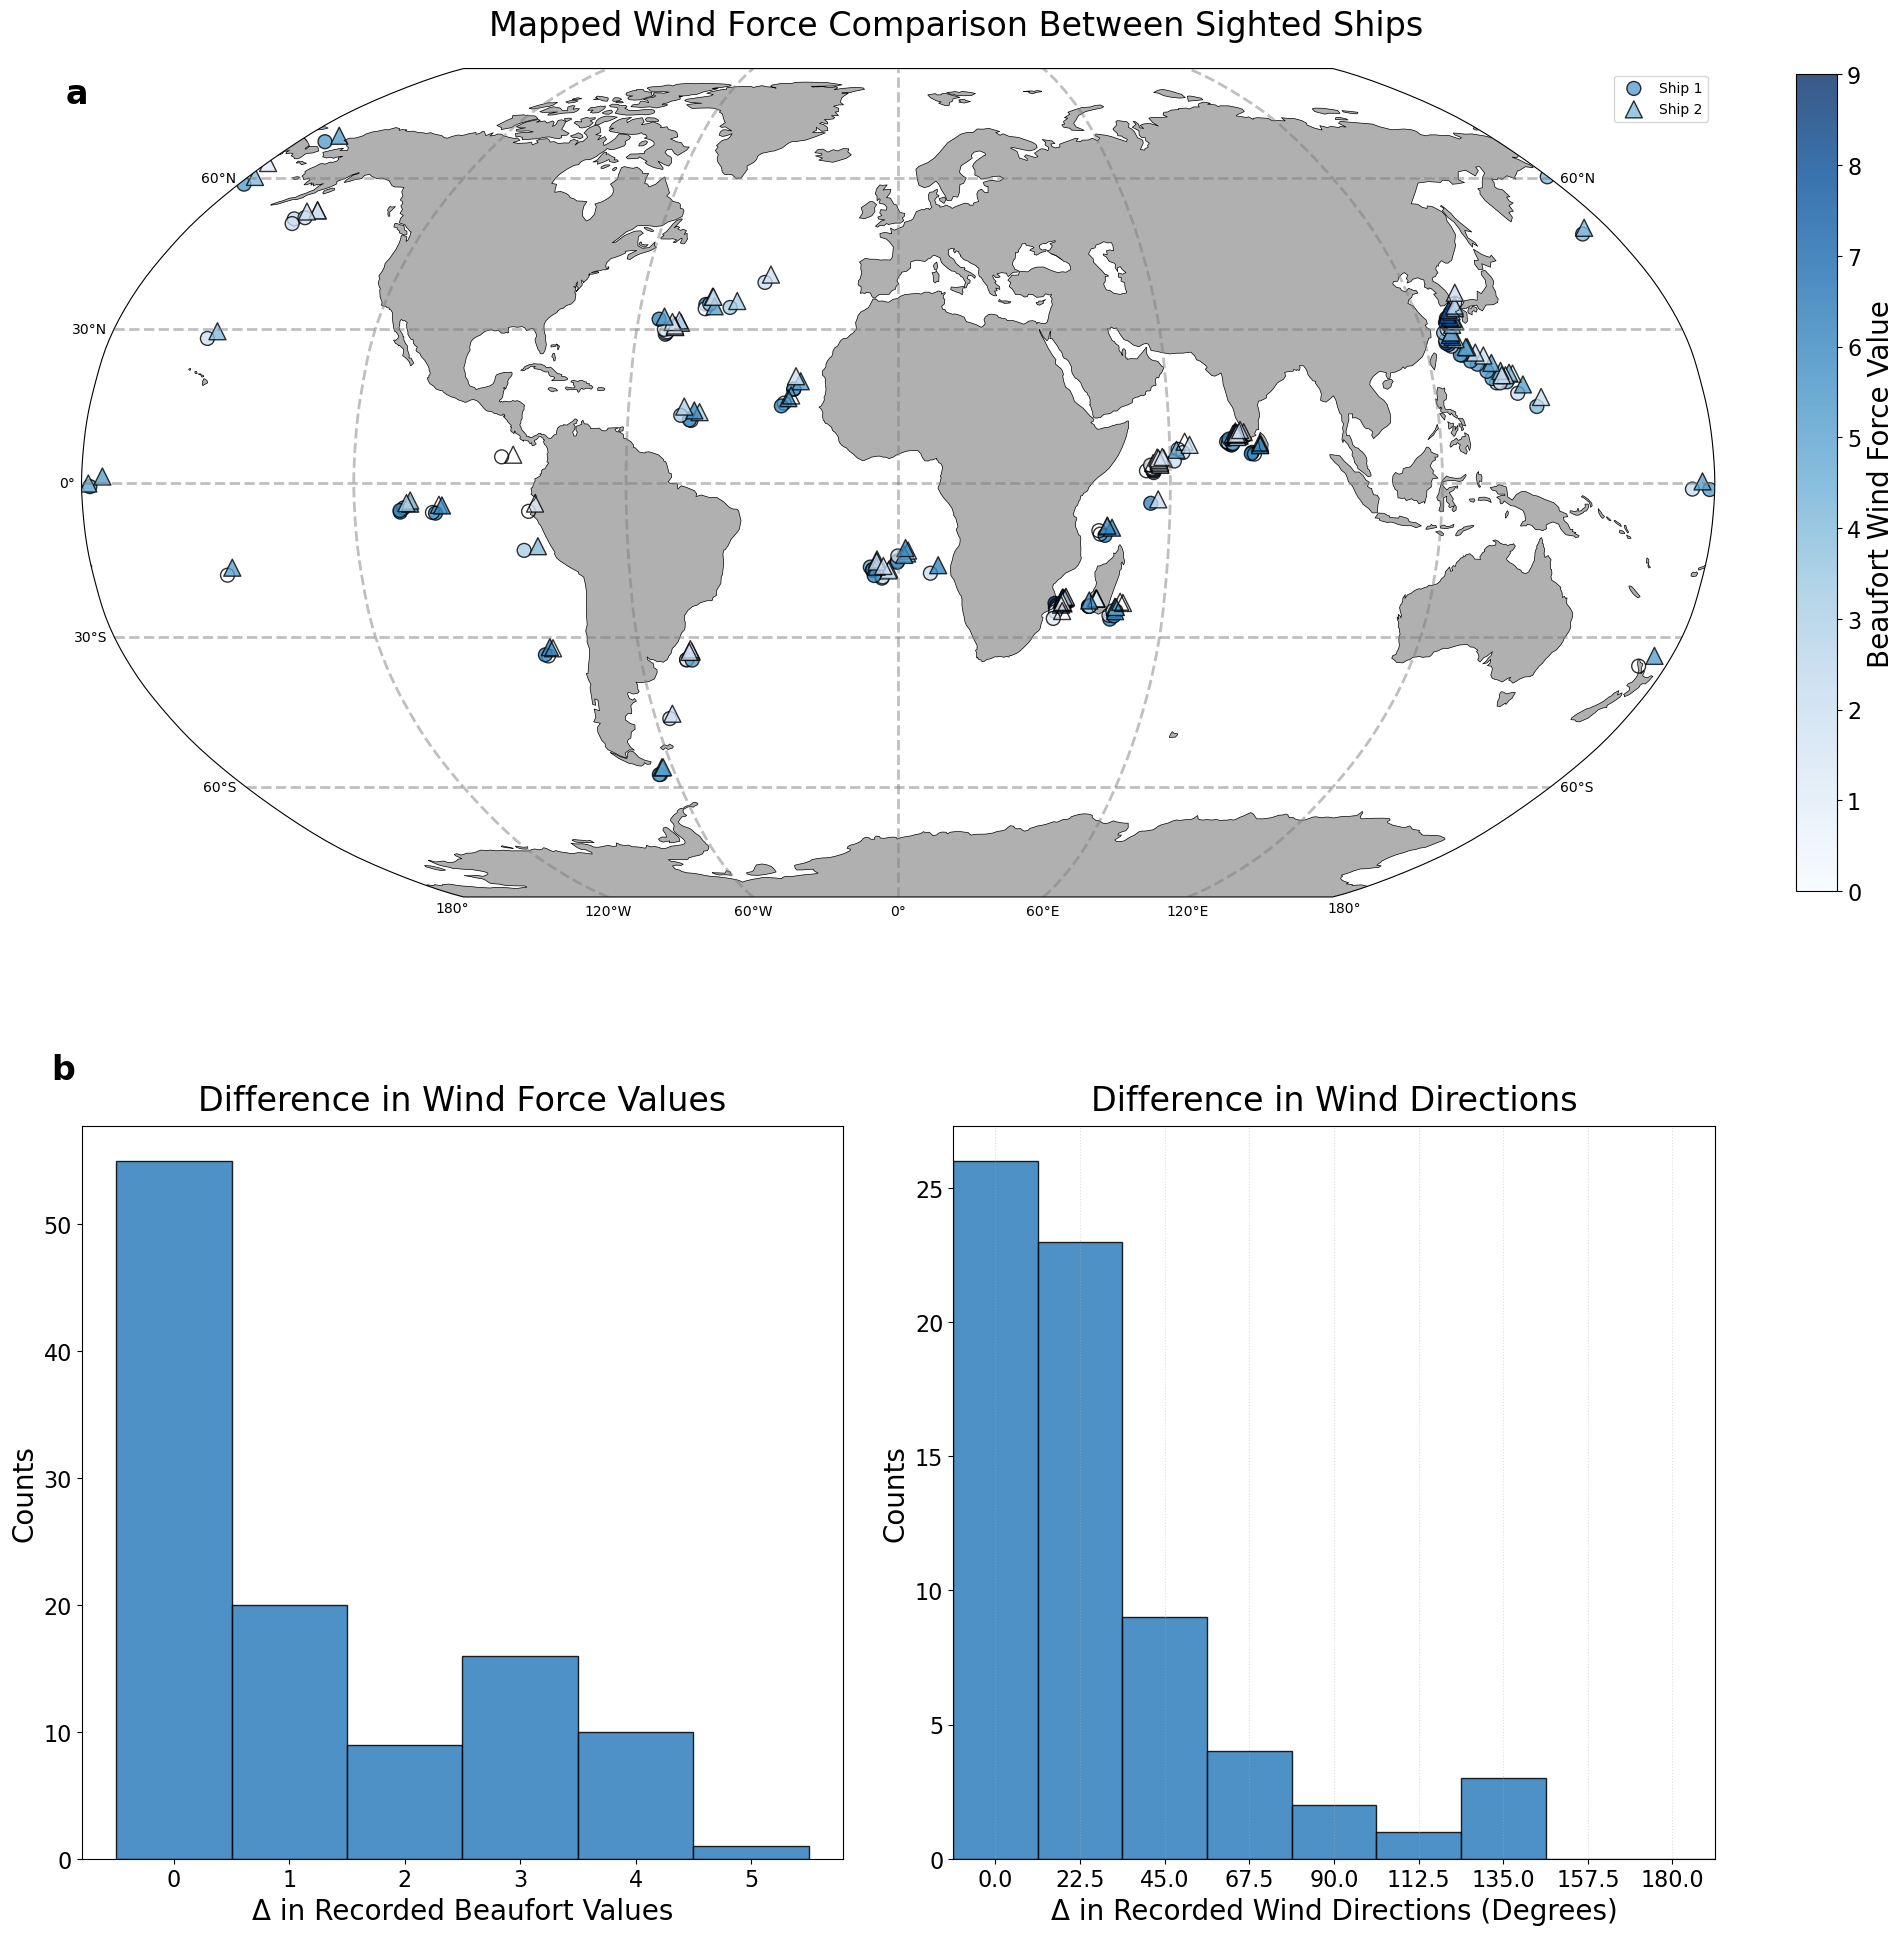

In [18]:
plot_map_with_bf_wd_abs_histograms(df_pairs, figures_path=Figures, save=False)

In [19]:
from utils.ship_sightings import summarize_bf_wd_agreement

stats = summarize_bf_wd_agreement(df_pairs)
print(stats)

{'bf': {'n': 111, 'count_le1': 75, 'pct_le1': 67.56756756756756}, 'wd': {'n': 68, 'count_le22_5': 49, 'pct_le22_5': 72.05882352941177, 'count_le45': 58, 'pct_le45': 85.29411764705883}}
